# FMATCH 5/10 — PSF weighting & aggregation

**PR topic**: turning a footprint's merged ancillary grid into the numbers that go in
the product.

- `weighting.py` — per-cell PSF weights over the tile. A narrow `PixelWeigher` ABC
  with two implementations: `RadialWeigher` (a boresight-centred Gaussian stand-in)
  and `AngularPSFWeigher` (the CERES-faithful weigher: every cell is projected into
  the instrument's along-scan/cross-scan angular frame and the real asymmetric PSF
  from PR 1 is evaluated there).
- `aggregation.py` — a registry of weighted statistics (`weighted_mean`,
  `weighted_std`, `weighted_log_mean`, `weighted_median`, ranked `weighted_mode`s
  for categorical fields, `cloud_weighted_mean`, `overcast_fraction`, …) plus the
  CERES 75%/95% **coverage rule** bookkeeping.

Every `VariableSpec` (PRs 2–3) names its aggregation strategy, so the engine is
completely generic: reader contracts in, one scalar per product variable out.

In [1]:
import sys
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from libera_utils.footprint_matching import aggregation, geometry
from libera_utils.footprint_matching.readers.era5 import ERA5Reader
from libera_utils.footprint_matching.tiling import TileManager
from libera_utils.footprint_matching.types import OperationalMode
from libera_utils.footprint_matching.weighting import AngularPSFWeigher, RadialWeigher
from tests.test_data.footprint_matching.fixtures import make_era5_netcdf_fixture

## Setup: one footprint, one merged tile

Reusing the earlier stack layers: geometry gives the footprint's bounding box, the
tile manager returns the merged ERA5 grid covering it.

In [3]:
workdir = Path(tempfile.mkdtemp(prefix="fmatch_nb05_"))
era5_path = make_era5_netcdf_fixture(
    workdir, lat_min=20.0, lat_max=50.0, lon_min=-120.0, lon_max=-90.0, n_lat=121, n_lon=121
)
manager = TileManager({"era5": ERA5Reader(era5_path)}, OperationalMode.CAM, prefetch_lookahead=0)

boresight = dict(boresight_lat_deg=38.0, boresight_lon_deg=-105.0)
viewing = dict(
    subsatellite_lat_deg=42.0,
    subsatellite_lon_deg=-104.2,
    viewing_zenith_deg=48.0,
)
bbox = geometry.compute_footprint_bounding_box(**boresight, **viewing)
tile = manager.get_data("era5", bbox)
print(
    f"merged tile {tile.data.shape[1]}x{tile.data.shape[2]} cells over "
    f"lat [{tile.bounds.lat_min}, {tile.bounds.lat_max}] lon [{tile.bounds.lon_min}, {tile.bounds.lon_max}]"
)

merged tile 17x9 cells over lat [36.0, 40.0] lon [-106.0, -104.0]


## 1. Two weighers, one contract

Both return a `WeightField` aligned to the tile grid. The radial stand-in is an
isotropic Gaussian in ground distance; the angular weigher shows the *real*
instrument response — elongated by the oblique view and asymmetric along-scan (the
detector's trailing tail; scan direction comes from the L1B `Cone_Angle_Rate` sign).

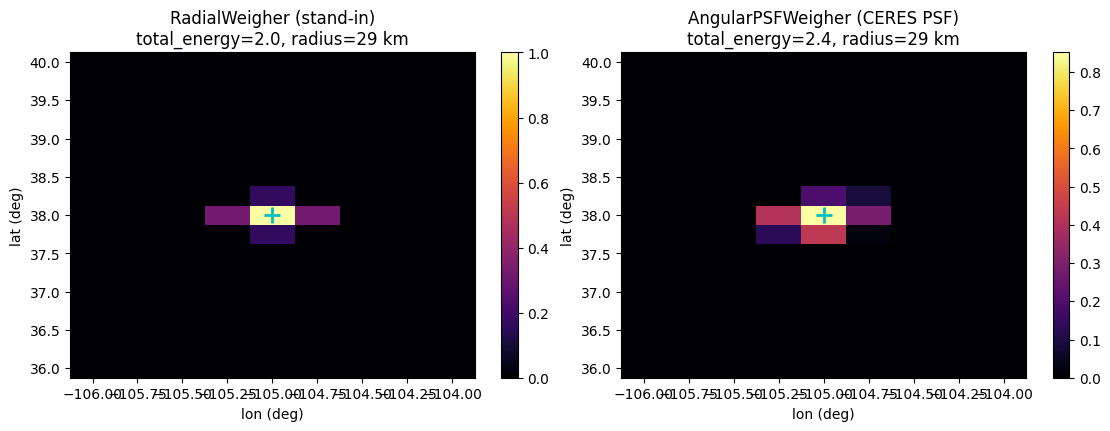

In [4]:
radial = RadialWeigher().weight_field(tile, **boresight, viewing_zenith_deg=viewing["viewing_zenith_deg"])
angular = AngularPSFWeigher().weight_field(
    tile,
    **boresight,
    viewing_zenith_deg=viewing["viewing_zenith_deg"],
    subsatellite_lat_deg=viewing["subsatellite_lat_deg"],
    subsatellite_lon_deg=viewing["subsatellite_lon_deg"],
    cone_angle_rate=1.0,  # scanning toward nadir
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, wf, title in [
    (axes[0], radial, "RadialWeigher (stand-in)"),
    (axes[1], angular, "AngularPSFWeigher (CERES PSF)"),
]:
    im = ax.pcolormesh(tile.lons, tile.lats, wf.weights, shading="auto", cmap="inferno")
    ax.plot(boresight["boresight_lon_deg"], boresight["boresight_lat_deg"], "c+", ms=12, mew=2)
    ax.set_title(f"{title}\ntotal_energy={wf.total_energy:.1f}, radius={wf.max_radius_km:.0f} km")
    ax.set_xlabel("lon (deg)")
    ax.set_ylabel("lat (deg)")
    fig.colorbar(im, ax=ax)
plt.show()

The cross marks the boresight. Note the angular field's asymmetry — more weight
trails the scan — which no distance-based kernel can produce.

## 2. Aggregation strategies

Each product variable names its strategy in its `VariableSpec`. The engine wraps
every strategy with the same coverage bookkeeping (`AggregationResult`).

In [5]:
values = tile.data[0]  # era5_wind_u10 on the tile grid
weights = angular.weights

for strategy in ("weighted_mean", "weighted_std", "weighted_median"):
    res = aggregation.aggregate(strategy, values, weights, total_energy=angular.total_energy)
    ((name, value),) = res.values.items()
    print(f"{strategy:18s} -> {value:8.3f}   coverage={res.coverage:.3f}  n_valid={res.n_valid}")

# Categorical example: a synthetic surface-type plane aggregated by ranked mode.
categories = (np.digitize(values, np.quantile(values[np.isfinite(values)], [0.4, 0.8]))).astype(float)
res = aggregation.aggregate("weighted_mode", categories, weights, n_categories=3)
print(f"{'weighted_mode':18s} -> {res.values}")

weighted_mean      ->    2.500   coverage=1.000  n_valid=8
weighted_std       ->    0.000   coverage=1.000  n_valid=8
weighted_median    ->    2.500   coverage=1.000  n_valid=8
weighted_mode      -> {'mode': 2.0, 'coverage_fractions': {2: 1.0}}


## 3. The CERES 75%/95% coverage rule

Coverage is the fraction of the PSF's total energy backed by usable data. Below we
punch a growing NaN hole in the tile (a missing ancillary region) and watch the
footprint go from **full** (≥95%) to **partial** (75–95%) to **rejected** (<75%).

In [6]:
lat_grid, lon_grid = np.meshgrid(tile.lats, tile.lons, indexing="ij")
dist = np.hypot(lat_grid - boresight["boresight_lat_deg"] + 0.3, lon_grid - boresight["boresight_lon_deg"] - 0.4)

print(f"{'hole radius':>12s} {'coverage':>9s} {'accept':>7s} {'partial':>8s}")
for hole_deg in (0.0, 0.5, 0.9, 1.6):
    damaged = values.copy()
    damaged[dist < hole_deg] = np.nan
    res = aggregation.aggregate("weighted_mean", damaged, weights, total_energy=angular.total_energy)
    usable = np.isfinite(damaged) & (weights > 0)
    accept, partial = aggregation.check_coverage(float(weights[usable].sum()), angular.total_energy)
    print(f"{hole_deg:>10.1f}°  {res.coverage:>9.3f} {accept!s:>7s} {partial!s:>8s}")

 hole radius  coverage  accept  partial
       0.0°      1.000    True    False
       0.5°      0.695   False    False
       0.9°      0.000   False    False
       1.6°      0.000   False    False


## 4. One call per reader: `aggregate_tile_variables`

The orchestrator's inner loop: give it a reader class, the merged tile, and the
weight field — it returns one scalar per *product* variable (means, their
`_standard_deviation` companions, ranked modes, …), dispatching each to its declared
strategy and sharing the per-plane masking work.

In [7]:
scalars = aggregation.aggregate_tile_variables(ERA5Reader, tile, angular)
for name, value in scalars.items():
    print(f"era5_{name:45s} {value:10.4f}")

era5_wind_u10                                          2.5000
era5_wind_u10_standard_deviation                       0.0000
era5_wind_v10                                         -1.5000
era5_wind_v10_standard_deviation                       0.0000
era5_temperature_2m                                  285.0000
era5_temperature_2m_standard_deviation                 0.0000
era5_dew_point_temperature_2m                        280.0000
era5_dew_point_temperature_2m_standard_deviation       0.0000
era5_surface_pressure                              101325.0000
era5_surface_pressure_standard_deviation               0.0000
era5_surface_geopotential                            500.0000
era5_surface_geopotential_standard_deviation           0.0000
era5_forecast_albedo                                   0.3000
era5_forecast_albedo_standard_deviation                0.0000


## 5. The efficiency angle

Along-track footprints reuse the same merged tile many times (~18× in realistic
segments). `AngularPSFWeigher` memoizes each tile's per-cell surface ECEF geometry
(closed-form, vectorized), so the dominant projection cost is paid once per distinct
tile rather than once per footprint:

In [8]:
weigher = AngularPSFWeigher()
t0 = time.perf_counter()
weigher.weight_field(
    tile,
    **boresight,
    viewing_zenith_deg=48.0,
    subsatellite_lat_deg=42.0,
    subsatellite_lon_deg=-104.2,
    cone_angle_rate=1.0,
)
cold = time.perf_counter() - t0

t0 = time.perf_counter()
n_repeat = 20
for i in range(n_repeat):  # consecutive footprints sharing the tile
    weigher.weight_field(
        tile,
        boresight_lat_deg=38.0 + 0.02 * i,
        boresight_lon_deg=-105.0,
        viewing_zenith_deg=48.0,
        subsatellite_lat_deg=42.0,
        subsatellite_lon_deg=-104.2,
        cone_angle_rate=1.0,
    )
warm = (time.perf_counter() - t0) / n_repeat
print(f"first footprint on tile: {cold * 1e3:.1f} ms; subsequent (cached cell geometry): {warm * 1e3:.1f} ms")

first footprint on tile: 0.7 ms; subsequent (cached cell geometry): 0.3 ms


## Where this goes next in the stack

The next PRs define the **product definitions** (which variables each FMATCH product
carries, at what dtype/units) and the **product assembly** (`product.py`) that runs
this weighting/aggregation loop over every footprint of a granule, feeding the
coverage flags and scalars you saw here into the output dataset.